In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
df_encoded = pd.read_csv('../data/insurance_cleaned.csv')
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [59]:
df_encoded.shape

(1337, 9)

In [60]:
df_encoded.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

# Phase - 5

In [61]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
print(X.shape, y.shape)

(1337, 8) (1337,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1069, 8) Test: (268, 8)


In [63]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 248.21,-101.54, 318.7 ,...,-391.76,-838.92,-659.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.109e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [64]:
print('Model trained:', model)
print('Intercept:', model.intercept_)
print('Coefficients:', dict(zip(X.columns, model.coef_)))

Model trained: LinearRegression()
Intercept: -11092.652295945958
Coefficients: {'age': np.float64(248.21072022470474), 'sex': np.float64(-101.5420539902726), 'bmi': np.float64(318.70144095235037), 'children': np.float64(533.0099887986963), 'smoker': np.float64(23077.764592868094), 'region_northwest': np.float64(-391.76145478360786), 'region_southeast': np.float64(-838.9196157269599), 'region_southwest': np.float64(-659.1397515529696)}


In [65]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(comparison)

        Actual     Predicted
0   8688.85885   8143.693884
1   5708.86700   5737.115683
2  11436.73815  14369.314876
3  38746.35510  31745.513636
4   4463.20510   8962.386657
5   9304.70190  13149.722353
6  38511.62830  30446.760679
7   2150.46900   1453.288813
8   7345.72660  10633.018402
9  10264.44210  11318.943794


# Phase - 6

In [66]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [67]:
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

MAE: 4177.05
MSE: 35478020.68
RMSE: 5956.34
R² Score: 0.8069


R² of 0.81 indicates the model captures most of the variance, but MAE/RMSE gap and the BMI-smoker interaction identified in EDA suggest a non-linear model or interaction terms would likely improve performance further.

Text(0.5, 1.0, 'Actual vs Predicted Charges')

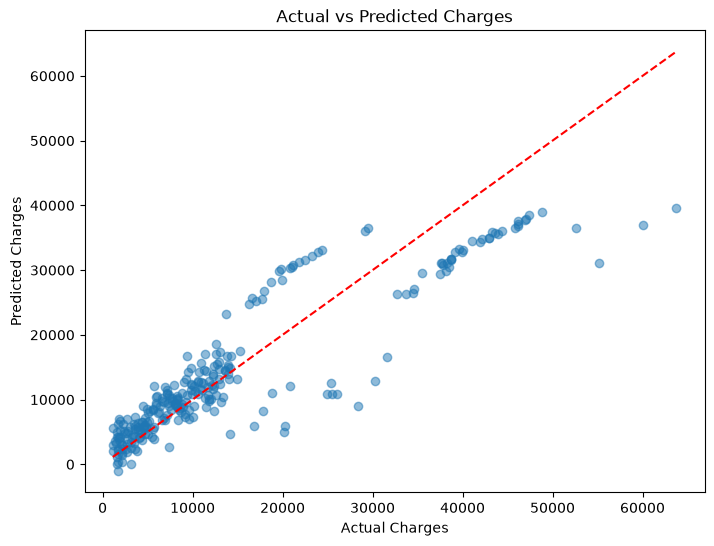

In [68]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')